In [28]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

import basegeospatialproject.config as config

In [2]:
ciren_gdf = gpd.read_file(f"{config.EXTERNAL_DATA_DIR}/estudio_agrologico_ciren.gpkg")

In [3]:
ciren_gdf["area"] = ciren_gdf["geometry"].area / 10**6

In [4]:
ciren_gdf.head(1)

,objectid,mslink,textcaus,layer,path,area,geometry
0,1,9100001,VI,REGIÓN ARAUCANÍA (CIREN 2013),crs='EPSG:3857' url='https://esri.ciren.cl/ser...,0.819912,"MULTIPOLYGON (((-8176766.583 -4663369.931, -81..."


In [5]:
ciren_grouped = ciren_gdf.groupby(["layer", "textcaus"])[["area"]].sum()

In [6]:
regiones_gdf = gpd.read_file(f"{config.EXTERNAL_DATA_DIR}/REGIONES_v1.shp")

In [7]:
regiones_gdf = regiones_gdf.to_crs(ciren_gdf.crs)

In [8]:
regiones_gdf["area"] = regiones_gdf["geometry"].area / 10**6

In [9]:
regiones_gdf

,CUT_REG,REGION,SUPERFICIE,geometry,area
0,04,Coquimbo,40587.80,"MULTIPOLYGON (((-7964271.706 -3725136.694, -79...",54997.986442
1,16,Ñuble,13089.22,"MULTIPOLYGON (((-8105124.257 -4318596.995, -81...",20372.805273
2,10,Los Lagos,48370.71,"MULTIPOLYGON (((-8331651.629 -5403258.139, -83...",87812.384556
3,01,Tarapacá,42318.82,"MULTIPOLYGON (((-7814614.895 -2362493.584, -78...",48311.410599
4,07,Maule,30311.18,"POLYGON ((-7855831.187 -4318875.337, -7855863....",45975.159302
5,15,Arica y Parinacota,16875.47,"POLYGON ((-7689085.472 -2158142.069, -7689059....",18865.959175
6,02,Antofagasta,126143.52,"MULTIPOLYGON (((-7874622.78 -2977683.486, -787...",150842.013350
7,09,La Araucanía,31799.88,"POLYGON ((-7952743.663 -4718421.744, -7952756....",52219.635535
8,14,Los Ríos,18319.98,"MULTIPOLYGON (((-8164740.333 -4851386.513, -81...",31260.722421
9,13,Metropolitana de Santiago,15398.38,"POLYGON ((-7845135.36 -4010340.639, -7845162.8...",22256.826968


In [10]:
regiones_gdf.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [11]:
ciren_grouped.reset_index()["layer"].unique()

array(['REGIÓN ARAUCANÍA (CIREN 2013)', 'REGIÓN ATACAMA (CIREN 2018)',
       'REGIÓN AYSÉN DEL GENERAL CARLOS IBAÑEZ DEL CAMPO (CIREN 2019)',
       'REGIÓN BIOBÍO (CIREN 2014)', 'REGIÓN COQUIMBO (CIREN 2014)',
       "REGIÓN LIBERTADOR GENERAL BERNARDO O'HIGGINS (CIREN 2010)",
       'REGIÓN LOS LAGOS (CIREN 2020)', 'REGIÓN LOS RÍOS (CIREN 2017)',
       'REGIÓN MAULE (CIREN 2011)', 'REGIÓN METROPOLITANA (CIREN 2015)',
       'REGIÓN VALPARAÍSO (CIREN 2016)', 'REGIÓN ÑUBLE (CIREN 2014)'],
      dtype=object)

In [12]:
def add_column_based_on_layer(df):
    # Mapping unique "layer" values to multiplication factors.
    new_df = df.copy()
    multiplier_mapping = {
        "REGIÓN ARAUCANÍA (CIREN 2013)": 52219.635535,
        "REGIÓN ATACAMA (CIREN 2018)": 96424.505252,
        "REGIÓN AYSÉN DEL GENERAL CARLOS IBAÑEZ DEL CAMPO (CIREN 2019)": 224945.913034,
        "REGIÓN BIOBÍO (CIREN 2014)": 38184.860868,
        "REGIÓN COQUIMBO (CIREN 2014)": 54997.986442,
        "REGIÓN LIBERTADOR GENERAL BERNARDO O'HIGGINS (CIREN 2010)": 24096.980307,
        "REGIÓN LOS LAGOS (CIREN 2020)": 87812.384556,
        "REGIÓN LOS RÍOS (CIREN 2017)": 31260.722421,
        "REGIÓN MAULE (CIREN 2011)": 45975.159302,
        "REGIÓN METROPOLITANA (CIREN 2015)": 22256.826968,
        "REGIÓN VALPARAÍSO (CIREN 2016)": 23018.397735,
        "REGIÓN ÑUBLE (CIREN 2014)": 20372.805273,
    }
    # Multiply the "area" by a layer-specific multiplier.
    multiplier_series = new_df["layer"].map(lambda x: multiplier_mapping.get(x, -99999999))
    new_df["area_adjusted"] = (new_df["area"] / multiplier_series) * 100
    return new_df

In [13]:
ciren_with_area = add_column_based_on_layer(ciren_grouped.reset_index())

In [14]:
ciren_with_area

,layer,textcaus,area,area_adjusted
0,REGIÓN ARAUCANÍA (CIREN 2013),I,90.171964,0.172678
1,REGIÓN ARAUCANÍA (CIREN 2013),II,3512.232935,6.725886
2,REGIÓN ARAUCANÍA (CIREN 2013),III,6468.280689,12.386683
3,REGIÓN ARAUCANÍA (CIREN 2013),IV,5626.866709,10.775385
4,REGIÓN ARAUCANÍA (CIREN 2013),N.C.,1457.358612,2.790825
...,...,...,...,...
93,REGIÓN ÑUBLE (CIREN 2014),IV,2183.769893,10.719044
94,REGIÓN ÑUBLE (CIREN 2014),N.C.,343.770610,1.687399
95,REGIÓN ÑUBLE (CIREN 2014),VI,1711.488079,8.400846
96,REGIÓN ÑUBLE (CIREN 2014),VII,5276.604422,25.900235


In [15]:
ciren_by_soil = ciren_with_area.pivot(index="layer", columns="textcaus", values="area")

In [20]:
ciren_by_soil["total"] = ciren_by_soil.sum(axis=1)

In [21]:
ciren_by_soil

textcaus,I,II,III,IV,N.C.,V,VI,VII,VIII,total
layer,,,,,,,,,,
REGIÓN ARAUCANÍA (CIREN 2013),90.171964,3512.232935,6468.280689,5626.866709,1457.358612,NaN,5404.792942,17053.985831,2842.862466,42456.552148
REGIÓN ATACAMA (CIREN 2018),2.125016,83.401210,202.747196,77.126273,146.765339,56.679788,37.430082,51.812740,67.870622,725.958265
REGIÓN AYSÉN DEL GENERAL CARLOS IBAÑEZ DEL CAMPO (CIREN 2019),NaN,203.135520,1172.362302,1558.226855,4202.903809,558.073193,2736.124606,14298.903450,30910.356576,55640.086311
REGIÓN BIOBÍO (CIREN 2014),364.766168,1503.886186,2863.633297,4006.305941,1182.152913,NaN,3526.758565,14642.888312,6844.691273,34935.082655
REGIÓN COQUIMBO (CIREN 2014),12.282846,122.826049,650.926630,289.558357,262.775605,NaN,146.667674,743.322368,358.542030,2586.901560
REGIÓN LIBERTADOR GENERAL BERNARDO O'HIGGINS (CIREN 2010),475.877532,1214.593349,2429.743553,1386.420858,770.691620,NaN,1783.785977,7123.346310,1308.800747,16493.259945
REGIÓN LOS LAGOS (CIREN 2020),149.936147,3036.095599,7448.598291,3703.939123,6069.912077,2563.183288,6508.195753,14763.377065,3799.677769,48042.915112
REGIÓN LOS RÍOS (CIREN 2017),NaN,1305.662755,2815.998057,2019.569078,1940.249858,NaN,4062.251613,11749.083596,1771.125284,25663.940242
REGIÓN MAULE (CIREN 2011),475.963961,1563.494612,5213.069119,4361.962016,852.549188,NaN,3005.115836,11584.521449,724.678442,27781.354624


In [22]:
ciren_by_soil.sort_values(by="total")

textcaus,I,II,III,IV,N.C.,V,VI,VII,VIII,total
layer,,,,,,,,,,
REGIÓN ATACAMA (CIREN 2018),2.125016,83.401210,202.747196,77.126273,146.765339,56.679788,37.430082,51.812740,67.870622,725.958265
REGIÓN COQUIMBO (CIREN 2014),12.282846,122.826049,650.926630,289.558357,262.775605,NaN,146.667674,743.322368,358.542030,2586.901560
REGIÓN METROPOLITANA (CIREN 2015),411.333861,1272.078181,1342.154123,748.535236,1499.635897,NaN,883.649490,4888.750588,1755.794395,12801.931771
REGIÓN VALPARAÍSO (CIREN 2016),285.934127,516.238887,996.612373,1081.097584,815.866894,4.358978,1353.395625,7034.631575,1286.624813,13374.760857
REGIÓN ÑUBLE (CIREN 2014),318.749608,2738.475138,2626.385416,2183.769893,343.770610,NaN,1711.488079,5276.604422,706.227351,15905.470517
REGIÓN LIBERTADOR GENERAL BERNARDO O'HIGGINS (CIREN 2010),475.877532,1214.593349,2429.743553,1386.420858,770.691620,NaN,1783.785977,7123.346310,1308.800747,16493.259945
REGIÓN LOS RÍOS (CIREN 2017),NaN,1305.662755,2815.998057,2019.569078,1940.249858,NaN,4062.251613,11749.083596,1771.125284,25663.940242
REGIÓN MAULE (CIREN 2011),475.963961,1563.494612,5213.069119,4361.962016,852.549188,NaN,3005.115836,11584.521449,724.678442,27781.354624
REGIÓN BIOBÍO (CIREN 2014),364.766168,1503.886186,2863.633297,4006.305941,1182.152913,NaN,3526.758565,14642.888312,6844.691273,34935.082655


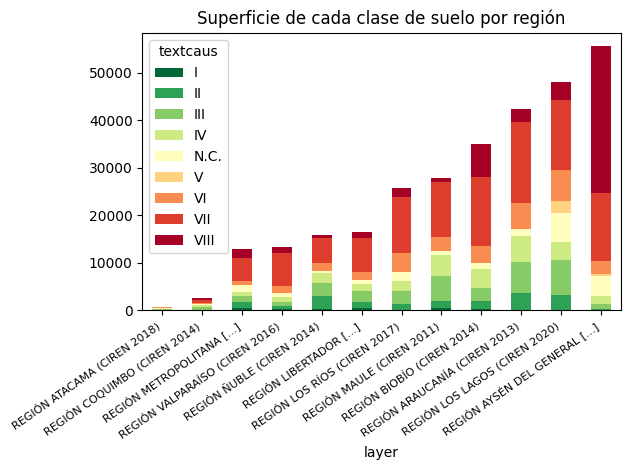

In [38]:
ax = (
    ciren_by_soil.sort_values(by="total")
    .drop(columns="total")
    .plot(
        kind="bar",
        stacked=True,
        colormap="RdYlGn_r",
        title=textwrap.fill(
            "Superficie de cada clase de suelo por región",
            width=50,
            max_lines=2,
        ),
    )
)

labels = [textwrap.fill(label.get_text(), width=30, max_lines=1) for label in ax.get_xticklabels()]

# Set wrapped labels and adjust alignment/rotation
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)

# Improve spacing and show plot
plt.tight_layout()
plt.show()

<Axes: xlabel='layer'>

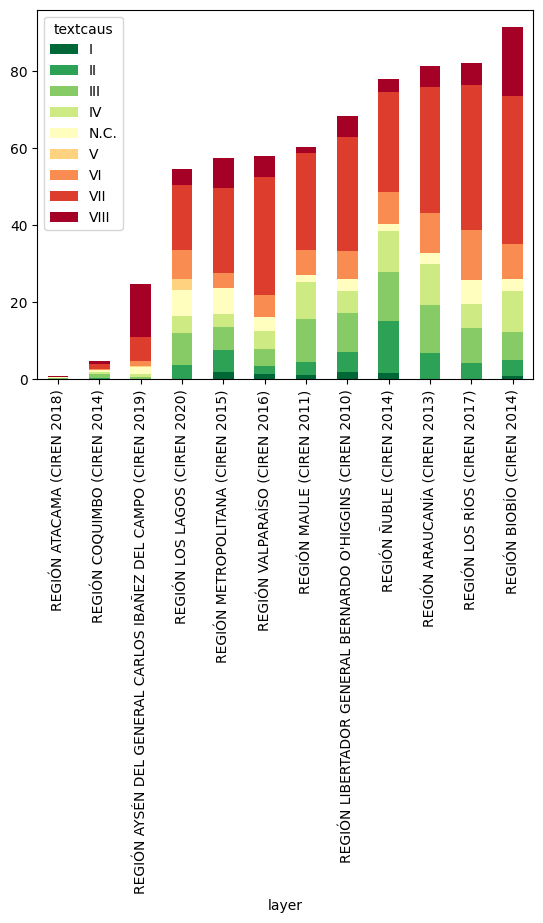

In [ ]:
ciren_by_soil_percentage = ciren_with_area.pivot(
    index="layer", columns="textcaus", values="area_adjusted"
)

ciren_by_soil_percentage["total"] = ciren_by_soil_percentage.sum(axis=1)

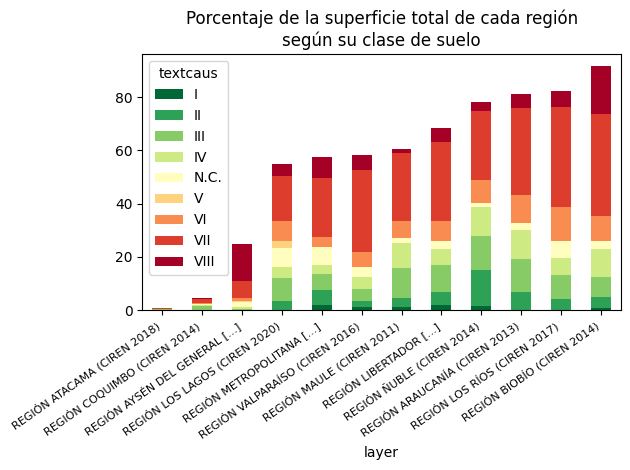

In [ ]:
ax = (
    ciren_by_soil_percentage.sort_values(by="total")
    .drop(columns="total")
    .plot(
        kind="bar",
        stacked=True,
        colormap="RdYlGn_r",
        title=textwrap.fill(
            "Porcentaje de la superficie total de cada región según su clase de suelo",
            width=50,
            max_lines=2,
        ),
    )
)

labels = [textwrap.fill(label.get_text(), width=30, max_lines=1) for label in ax.get_xticklabels()]

# Set wrapped labels and adjust alignment/rotation
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)

# Improve spacing and show plot
plt.tight_layout()
plt.show()